In [1]:
import pandas as pd
shots_df = pd.read_csv('/Users/aadvikmazumdar/Projects/OnTarget/data/processed/shots.csv')

In [2]:
print(type(shots_df))
print(shots_df.head() if hasattr(shots_df, 'head') else shots_df[:2])

<class 'pandas.DataFrame'>
       id  minute       result      X      Y        xG           player h_a  \
0  388074       5  MissedShots  0.753  0.491  0.021301         Raphinha   h   
1  388076      11    SavedShot  0.928  0.567  0.452016  Patrick Bamford   h   
2  388078      18  BlockedShot  0.767  0.634  0.019301    Stuart Dallas   h   
3  388079      18  MissedShots  0.741  0.605  0.015293    Jack Harrison   h   
4  388082      26  MissedShots  0.763  0.593  0.022445         Raphinha   h   

   player_id situation  ...  player_assisted lastAction          league  year  \
0       8026  OpenPlay  ...    Mateusz Klich       Pass  premier_league  2020   
1        822  OpenPlay  ...   Ezgjan Alioski       Pass  premier_league  2020   
2       8718  OpenPlay  ...              NaN        NaN  premier_league  2020   
3       8720  OpenPlay  ...              NaN        NaN  premier_league  2020   
4       8026  OpenPlay  ...   Ezgjan Alioski       Pass  premier_league  2020   

  phase  go

In [3]:
shots_df['situation'].value_counts()

situation
OpenPlay          164467
FromCorner         35818
SetPiece           13935
DirectFreekick      7549
Penalty             2907
Name: count, dtype: int64

In [4]:
shots_df['lastAction'].value_counts()


lastAction
Pass               80722
Cross              31600
Aerial             18556
Chipped            10561
Standard           10456
Rebound            10351
TakeOn             10208
BallRecovery        5839
BallTouch           5226
HeadPass            4882
Throughball         4418
LayOff              1183
Dispossessed        1109
CornerAwarded        514
Tackle               478
Foul                 474
BlockedPass          360
Goal                 176
End                  143
Challenge            112
Clearance            100
Interception          93
OffsidePass           75
Card                  62
Save                  46
SubstitutionOn        37
GoodSkill             29
OffsideProvoked       22
KeeperPickup          14
FormationChange        9
Error                  5
Start                  4
ChanceMissed           3
ShieldBallOpp          2
PenaltyFaced           1
Name: count, dtype: int64

In [5]:
shots_df['shotType'].value_counts()

shotType
RightFoot        111633
LeftFoot          72303
Head              39723
OtherBodyPart      1017
Name: count, dtype: int64

In [6]:
# sort for sequential analysis
shots_df = shots_df.sort_values(['match_id', 'minute']).reset_index(drop=True)

# shift to get previous shot context
shots_df['prev_match_id'] = shots_df['match_id'].shift(1)
shots_df['prev_h_a']      = shots_df['h_a'].shift(1)
shots_df['prev_minute']   = shots_df['minute'].shift(1)

# rapid transition: opposite team shot within 2 minutes
shots_df['is_rapid_transition'] = (
    (shots_df['match_id'] == shots_df['prev_match_id']) &
    (shots_df['h_a'] != shots_df['prev_h_a']) &
    (shots_df['minute'] - shots_df['prev_minute'] <= 2)
)

In [7]:
# hard exclusions mask
EXCLUDE_SITUATIONS  = ['Penalty', 'FromCorner', 'SetPiece', 'DirectFreekick']
EXCLUDE_LASTACTIONS = ['Rebound', 'Aerial', 'CornerAwarded', 'Foul', 'Cross']

excluded = (
    shots_df['situation'].isin(EXCLUDE_SITUATIONS) |
    shots_df['lastAction'].isin(EXCLUDE_LASTACTIONS)
)

# counter actions — only valid when is_rapid_transition == True
COUNTER_ACTIONS = [
    'BallRecovery', 'Interception', 'Dispossessed',
    'TakeOn', 'Tackle', 'Challenge', 'Throughball'
]

# composite score
shots_df['counter_score'] = 0

shots_df.loc[
    ~excluded &
    shots_df['is_rapid_transition'] &
    shots_df['lastAction'].isin(COUNTER_ACTIONS),
    'counter_score'
] += 1

shots_df.loc[
    ~excluded &
    (shots_df['X'] > 0.85) &
    (shots_df['Y'] > 0.3) &
    (shots_df['Y'] < 0.7),
    'counter_score'
] += 1

# counter flag
shots_df['is_counter'] = shots_df['counter_score'] >= 2

print(shots_df['counter_score'].value_counts().sort_index())
print()
print(f"counters (score=2):          {(shots_df['counter_score'] == 2).sum()}")
print(f"Total flagged:                       {shots_df['is_counter'].sum()}")
print(f"As % of all shots:                   {shots_df['is_counter'].mean():.1%}")

counter_score
0    165588
1     57155
2      1933
Name: count, dtype: int64

counters (score=2):          1933
Total flagged:                       1933
As % of all shots:                   0.9%


In [8]:
# tiered labeling instead of binary is_counter
shots_df['counter_tier'] = shots_df['counter_score'].map({
    0: 'regular_play',
    1: 'elevated_threat',
    2: 'high_confidence_counter'
})

print(shots_df['counter_tier'].value_counts())
print()
print(shots_df.groupby('counter_tier').agg(
    shots=('counter_tier', 'count'),
    goals=('result', lambda x: (x == 'Goal').sum()),
    avg_xG=('xG', 'mean')
).assign(
    conversion=lambda d: d['goals']/d['shots'],
    pct_of_total=lambda d: d['shots']/d['shots'].sum()
).round(3))

counter_tier
regular_play               165588
elevated_threat             57155
high_confidence_counter      1933
Name: count, dtype: int64

                          shots  goals  avg_xG  conversion  pct_of_total
counter_tier                                                            
elevated_threat           57155   9665   0.185       0.169         0.254
high_confidence_counter    1933    475   0.255       0.246         0.009
regular_play             165588  14387   0.093       0.087         0.737


In [9]:
situation_breakdown = shots_df.groupby(['league', 'situation']).agg(
    shots=('situation', 'count'),
    goals=('result', lambda x: (x == 'Goal').sum()),
    avg_xG=('xG', 'mean')
).assign(
    conversion=lambda d: d['goals']/d['shots']
).round(3)

print(situation_breakdown)

                               shots  goals  avg_xG  conversion
league         situation                                       
bundesliga     DirectFreekick   1175     81   0.063       0.069
               FromCorner       6347    537   0.091       0.085
               OpenPlay        29059   3397   0.120       0.117
               Penalty           487    376   0.757       0.772
               SetPiece         2736    271   0.119       0.099
la_liga        DirectFreekick   1610     65   0.062       0.040
               FromCorner       6973    532   0.088       0.076
               OpenPlay        32795   3417   0.115       0.104
               Penalty           624    472   0.743       0.756
               SetPiece         2848    229   0.109       0.080
ligue_1        DirectFreekick   1533     82   0.059       0.053
               FromCorner       6675    553   0.091       0.083
               OpenPlay        31529   3380   0.117       0.107
               Penalty           644    

In [10]:
tier_by_league = shots_df.groupby(['league', 'counter_tier']).agg(
    shots=('counter_tier', 'count'),
    goals=('result', lambda x: (x == 'Goal').sum()),
    avg_xG=('xG', 'mean')
).assign(
    conversion=lambda d: d['goals']/d['shots'],
    pct_of_league=lambda d: d['shots'] / d.groupby(level=0)['shots'].transform('sum')
).round(3)

print(tier_by_league)

                                        shots  goals  avg_xG  conversion  \
league         counter_tier                                                
bundesliga     elevated_threat          10366   1859   0.191       0.179   
               high_confidence_counter    368    101   0.265       0.274   
               regular_play             29070   2702   0.095       0.093   
la_liga        elevated_threat          10841   1867   0.190       0.172   
               high_confidence_counter    364     84   0.256       0.231   
               regular_play             33645   2764   0.092       0.082   
ligue_1        elevated_threat          10921   1889   0.190       0.173   
               high_confidence_counter    380     98   0.260       0.258   
               regular_play             31571   2792   0.095       0.088   
premier_league elevated_threat          13415   2147   0.180       0.160   
               high_confidence_counter    441     94   0.246       0.213   
            

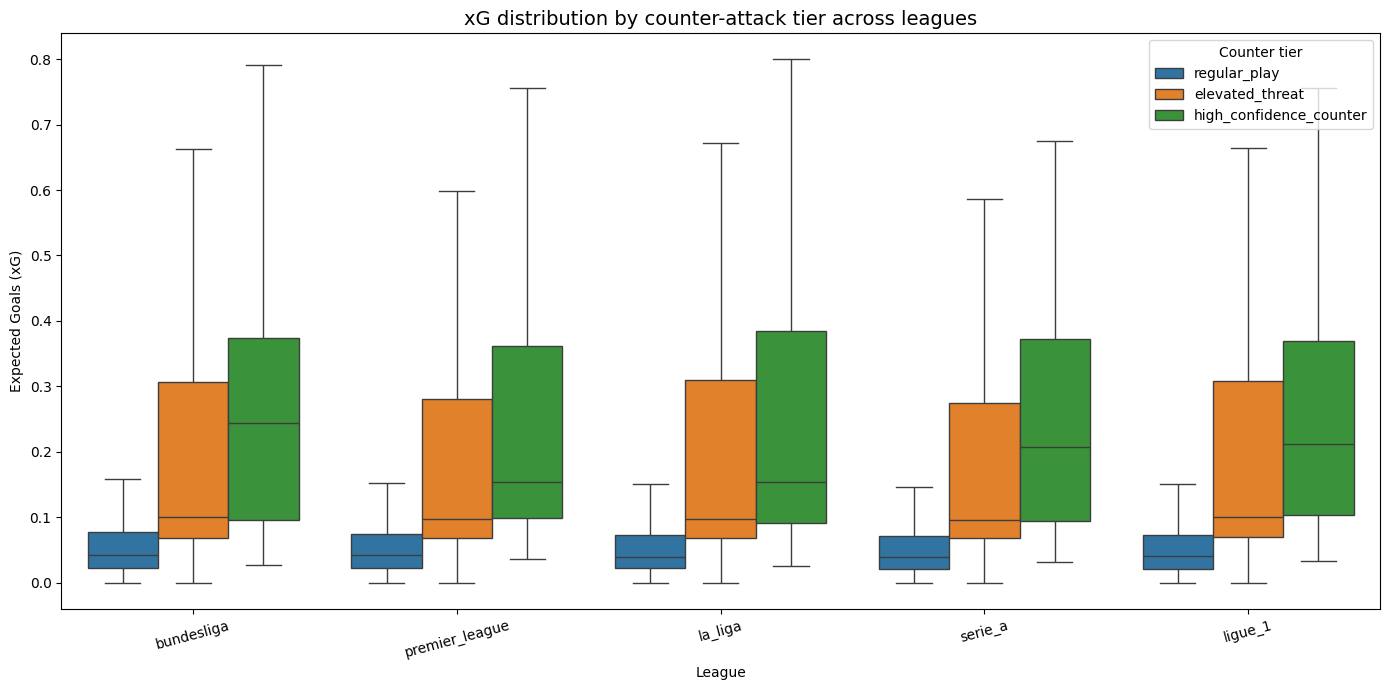

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# reorder for consistent tier sequence
tier_order = ['regular_play', 'elevated_threat', 'high_confidence_counter']
league_order = ['bundesliga', 'premier_league', 'la_liga', 'serie_a', 'ligue_1']

fig, ax = plt.subplots(figsize=(14, 7))

sns.boxplot(
    data=shots_df,
    x='league',
    y='xG',
    hue='counter_tier',
    hue_order=tier_order,
    order=league_order,
    showfliers=False,  # hide outlier dots — xG has extreme tail, keeps plot readable
    ax=ax
)

ax.set_title('xG distribution by counter-attack tier across leagues', fontsize=14)
ax.set_xlabel('League')
ax.set_ylabel('Expected Goals (xG)')
ax.legend(title='Counter tier', loc='upper right')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

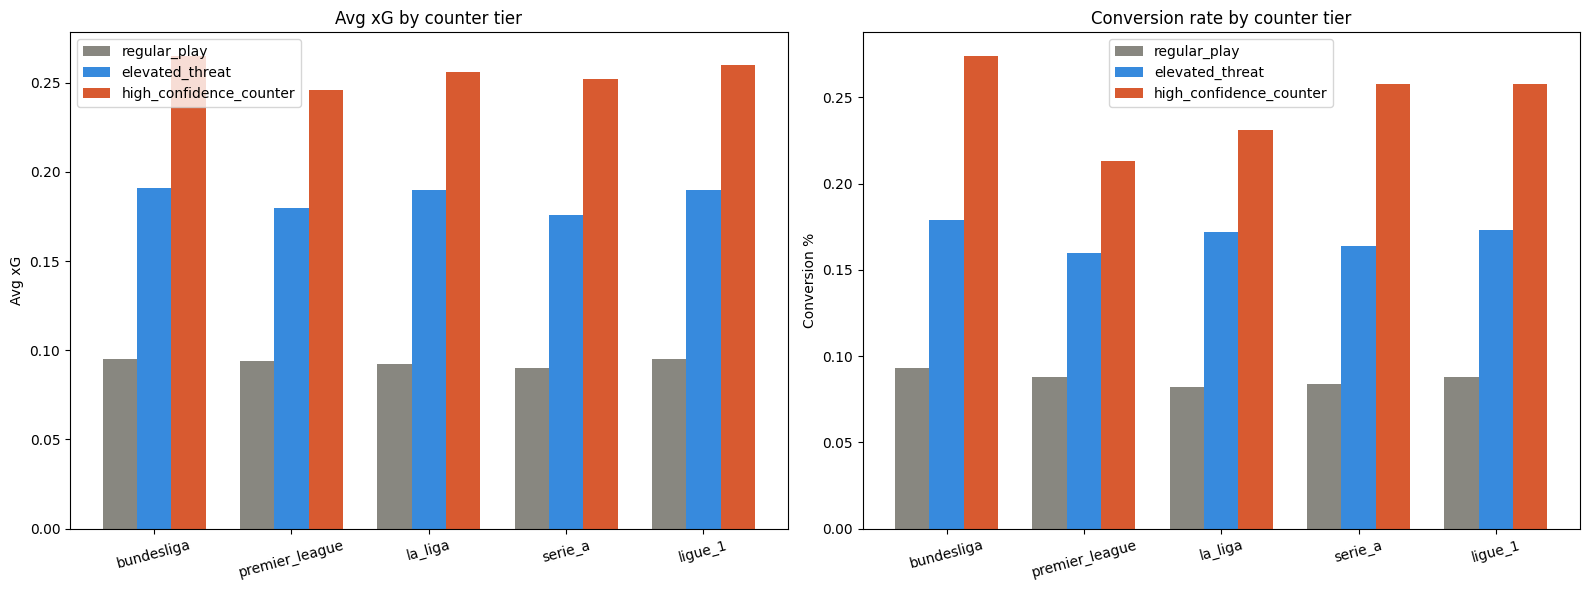

In [12]:
import matplotlib.pyplot as plt
import numpy as np

tier_order = ['regular_play', 'elevated_threat', 'high_confidence_counter']
league_order = ['bundesliga', 'premier_league', 'la_liga', 'serie_a', 'ligue_1']
colors = ['#888780', '#378ADD', '#D85A30']  # gray, blue, coral — regular/elevated/counter

pivot_xg = tier_by_league.reset_index().pivot(index='league', columns='counter_tier', values='avg_xG')
pivot_xg = pivot_xg.reindex(league_order)[tier_order]

pivot_conv = tier_by_league.reset_index().pivot(index='league', columns='counter_tier', values='conversion')
pivot_conv = pivot_conv.reindex(league_order)[tier_order]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(league_order))
width = 0.25

for i, tier in enumerate(tier_order):
    axes[0].bar(x + i*width, pivot_xg[tier], width, label=tier, color=colors[i])
    axes[1].bar(x + i*width, pivot_conv[tier], width, label=tier, color=colors[i])

axes[0].set_title('Avg xG by counter tier')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(league_order, rotation=15)
axes[0].set_ylabel('Avg xG')
axes[0].legend()

axes[1].set_title('Conversion rate by counter tier')
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(league_order, rotation=15)
axes[1].set_ylabel('Conversion %')
axes[1].legend()

plt.tight_layout()
plt.show()

In [13]:
cross_analysis = shots_df[shots_df['is_cross'] == True].groupby(['cross_side', 'phase']).agg(
    shots=('is_cross', 'count'),
    goals=('result', lambda x: (x == 'Goal').sum()),
    avg_xG=('xG', 'mean')
).assign(
    conversion=lambda d: d['goals']/d['shots']
).round(3)

print(cross_analysis)

# cross vs open play xG comparison
cross_vs_open = shots_df.groupby('is_cross').agg(
    shots=('is_cross', 'count'),
    goals=('result', lambda x: (x == 'Goal').sum()),
    avg_xG=('xG', 'mean')
).assign(conversion=lambda d: d['goals']/d['shots']).round(3)

print(cross_vs_open)

                  shots  goals  avg_xG  conversion
cross_side phase                                  
left       AT       802     98   0.139       0.122
           Q1      3931    461   0.149       0.117
           Q2      3228    401   0.148       0.124
           Q3      4542    562   0.150       0.124
           Q4      3183    378   0.153       0.119
right      AT       775     96   0.143       0.124
           Q1      3884    501   0.151       0.129
           Q2      3262    403   0.152       0.124
           Q3      4565    585   0.154       0.128
           Q4      3428    403   0.147       0.118
           shots  goals  avg_xG  conversion
is_cross                                   
False     193076  20639   0.113       0.107
True       31600   3888   0.150       0.123


In [14]:
shots_df['cross_zone'] = np.where(
    shots_df['is_cross'] & (shots_df['Y'] > 0.3) & (shots_df['Y'] < 0.7),
    'central',
    np.where(shots_df['is_cross'], 'wide', None)
)

print(shots_df[shots_df['is_cross']]['cross_zone'].value_counts())

cross_zone
central    31141
wide         459
Name: count, dtype: int64


In [15]:
phase_breakdown = shots_df.groupby('phase').agg(
    shots=('phase', 'count'),
    goals=('result', lambda x: (x == 'Goal').sum()),
    avg_xG=('xG', 'mean')
).assign(
    conversion=lambda d: d['goals']/d['shots']
).round(3)

print(phase_breakdown)

       shots  goals  avg_xG  conversion
phase                                  
AT     11181   1294   0.126       0.116
Q1     53722   5761   0.115       0.107
Q2     46858   4959   0.116       0.106
Q3     65397   7220   0.119       0.110
Q4     47518   5293   0.120       0.111


In [16]:
phase_gamestate = shots_df.groupby(['phase', 'game_state']).agg(
    shots=('phase', 'count'),
    goals=('result', lambda x: (x == 'Goal').sum()),
    avg_xG=('xG', 'mean')
).assign(
    conversion=lambda d: d['goals']/d['shots'],
    pct_of_phase=lambda d: d['shots'] / d.groupby(level=0)['shots'].transform('sum')
).round(3)

print(phase_gamestate)

                     shots  goals  avg_xG  conversion  pct_of_phase
phase game_state                                                   
AT    drawing         3113    291   0.113       0.093         0.278
      losing          4578    170   0.083       0.037         0.409
      winning_by_1    1669    323   0.173       0.194         0.149
      winning_by_2+   1821    510   0.211       0.280         0.163
Q1    drawing        13213   1101   0.105       0.083         0.246
      losing         16622    995   0.097       0.060         0.309
      winning_by_1   10794   1310   0.124       0.121         0.201
      winning_by_2+  13093   2355   0.141       0.180         0.244
Q2    drawing        11638    969   0.108       0.083         0.248
      losing         14687    849   0.094       0.058         0.313
      winning_by_1    9555   1049   0.119       0.110         0.204
      winning_by_2+  10978   2092   0.149       0.191         0.234
Q3    drawing        16405   1370   0.108       

In [17]:
shots_df['team_name'] = np.where(
    shots_df['h_a'] == 'h',
    shots_df['h_team'],
    shots_df['a_team']
)

print(shots_df[['h_team', 'a_team', 'h_a', 'team_name']].head())

     h_team  a_team h_a team_name
0  Bordeaux  Nantes   a    Nantes
1  Bordeaux  Nantes   a    Nantes
2  Bordeaux  Nantes   a    Nantes
3  Bordeaux  Nantes   h  Bordeaux
4  Bordeaux  Nantes   h  Bordeaux


In [18]:
team_phase_state = shots_df.groupby(['team_name', 'league', 'year', 'phase', 'game_state', 'h_a']).agg(
    shots=('phase', 'count'),
    avg_xG=('xG', 'mean')
).reset_index()

print(team_phase_state.shape)
print(team_phase_state.head(10))

(17901, 8)
  team_name   league  year phase     game_state h_a  shots    avg_xG
0  AC Milan  serie_a  2020    AT        drawing   a      1  0.014459
1  AC Milan  serie_a  2020    AT        drawing   h     10  0.166889
2  AC Milan  serie_a  2020    AT         losing   h      6  0.077214
3  AC Milan  serie_a  2020    AT   winning_by_1   a      3  0.081670
4  AC Milan  serie_a  2020    AT   winning_by_1   h      1  0.103168
5  AC Milan  serie_a  2020    AT  winning_by_2+   a      5  0.337611
6  AC Milan  serie_a  2020    AT  winning_by_2+   h      1  0.051069
7  AC Milan  serie_a  2020    Q1        drawing   a      4  0.066078
8  AC Milan  serie_a  2020    Q1        drawing   h     16  0.090948
9  AC Milan  serie_a  2020    Q1         losing   a      4  0.064096


In [19]:
print(team_phase_state['shots'].describe())
print()
print((team_phase_state['shots'] < 5).sum(), 'rows have fewer than 5 shots')
print((team_phase_state['shots'] < 10).sum(), 'rows have fewer than 10 shots')

count    17901.000000
mean        12.551031
std          9.567878
min          1.000000
25%          5.000000
50%         11.000000
75%         18.000000
max        103.000000
Name: shots, dtype: float64

4087 rows have fewer than 5 shots
8159 rows have fewer than 10 shots


In [20]:
team_phase_state = shots_df.groupby(['team_name', 'league', 'year', 'phase', 'game_state', 'h_a']).agg(
    shots=('phase', 'count'),
    goals=('result', lambda x: (x == 'Goal').sum()),
    avg_xG=('xG', 'mean')
).reset_index()

team_phase_state['conversion'] = (team_phase_state['goals'] / team_phase_state['shots']).round(3)

def confidence_tier(shots):
    if shots >= 20:
        return 'high'
    elif shots >= 10:
        return 'medium'
    elif shots >= 5:
        return 'low'
    else:
        return 'very_low'

team_phase_state['confidence'] = team_phase_state['shots'].apply(confidence_tier)

liverpool = team_phase_state[team_phase_state['team_name'] == 'Liverpool'].sort_values(
    ['year', 'phase', 'game_state', 'h_a']
)
print(liverpool.to_string(index=False))

team_name         league  year phase    game_state h_a  shots  goals   avg_xG  conversion confidence
Liverpool premier_league  2020    AT       drawing   a      1      0 0.097371       0.000   very_low
Liverpool premier_league  2020    AT        losing   a      2      0 0.046496       0.000   very_low
Liverpool premier_league  2020    AT        losing   h      5      0 0.027357       0.000        low
Liverpool premier_league  2020    AT  winning_by_1   a      4      1 0.068534       0.250   very_low
Liverpool premier_league  2020    AT  winning_by_1   h      1      0 0.340546       0.000   very_low
Liverpool premier_league  2020    AT winning_by_2+   a      6      0 0.252408       0.000        low
Liverpool premier_league  2020    AT winning_by_2+   h      1      0 0.048885       0.000   very_low
Liverpool premier_league  2020    Q1       drawing   a     18      2 0.123154       0.111     medium
Liverpool premier_league  2020    Q1       drawing   h     18      2 0.077492       0.111  

In [21]:
momentum_by_state = shots_df.groupby(['team_name', 'league', 'year', 'phase', 'game_state']).agg(
    shots=('phase', 'count'),
    goals=('result', lambda x: (x == 'Goal').sum()),
    avg_xG=('xG', 'mean')
).reset_index()

momentum_by_state['conversion'] = (momentum_by_state['goals'] / momentum_by_state['shots']).round(3)

def confidence_tier(shots):
    if shots >= 20:
        return 'high'
    elif shots >= 10:
        return 'medium'
    elif shots >= 5:
        return 'low'
    else:
        return 'very_low'

momentum_by_state['confidence'] = momentum_by_state['shots'].apply(confidence_tier)

print(momentum_by_state.shape)
print(momentum_by_state.head())

(9495, 10)
  team_name   league  year phase     game_state  shots  goals    avg_xG  \
0  AC Milan  serie_a  2020    AT        drawing     11      2  0.153032   
1  AC Milan  serie_a  2020    AT         losing      6      0  0.077214   
2  AC Milan  serie_a  2020    AT   winning_by_1      4      1  0.087045   
3  AC Milan  serie_a  2020    AT  winning_by_2+      6      3  0.289854   
4  AC Milan  serie_a  2020    Q1        drawing     20      1  0.085974   

   conversion confidence  
0       0.182     medium  
1       0.000        low  
2       0.250   very_low  
3       0.500        low  
4       0.050       high  


In [22]:
import plotly.express as px

phase_order = ['Q1', 'Q2', 'Q3', 'Q4', 'AT']

def plot_momentum(team, league, year):
    subset = momentum_by_state[
        (momentum_by_state['team_name'] == team) &
        (momentum_by_state['league'] == league) &
        (momentum_by_state['year'] == year)
    ].copy()
    
    subset['phase'] = pd.Categorical(subset['phase'], categories=phase_order, ordered=True)
    subset = subset.sort_values('phase')
    
    fig = px.line(
        subset,
        x='phase',
        y='avg_xG',
        color='game_state',
        markers=True,
        hover_data=['shots', 'confidence', 'conversion'],
        title=f'{team} {year} — avg xG per shot by phase and game state'
    )
    fig.update_layout(yaxis_title='Avg xG per shot', xaxis_title='Match phase')
    fig.show()

plot_momentum('Liverpool', 'premier_league', 2022)

In [25]:
rosters_df = pd.read_csv("/Users/aadvikmazumdar/Projects/OnTarget/data/processed/rosters.csv")
rosters_df.columns.to_list()

['id',
 'goals',
 'own_goals',
 'shots',
 'xG',
 'time',
 'player_id',
 'team_id',
 'position',
 'player',
 'h_a',
 'yellow_card',
 'red_card',
 'roster_in',
 'roster_out',
 'key_passes',
 'assists',
 'xA',
 'xGChain',
 'xGBuildup',
 'positionOrder',
 'league',
 'year',
 'match_id']

In [26]:
team_counter_rate = shots_df.groupby(['team_name', 'league', 'year']).agg(
    total_shots=('counter_tier', 'count'),
    counter_shots=('counter_score', lambda x: (x >= 2).sum())
).reset_index()

team_counter_rate['counter_rate'] = (team_counter_rate['counter_shots'] / team_counter_rate['total_shots']).round(4)

print(team_counter_rate.head())

  team_name   league  year  total_shots  counter_shots  counter_rate
0  AC Milan  serie_a  2020          558              5        0.0090
1  AC Milan  serie_a  2021          605              5        0.0083
2  AC Milan  serie_a  2022          553              4        0.0072
3  AC Milan  serie_a  2023          564             11        0.0195
4  AC Milan  serie_a  2024          567              9        0.0159


In [27]:
print(rosters_df['position'].value_counts())

position
Sub    76224
DC     42170
MC     31613
FW     23817
GK     17963
DL     12628
DR     12627
DMC    11393
AMC    11180
AMR     4881
AML     4881
MR      4527
ML      4527
DMR     4346
DML     4346
FWR     3351
FWL     3351
Name: count, dtype: int64


In [28]:
DEFENDER_POSITIONS = ['DC', 'DL', 'DR']

# derive team_name in rosters_df, same pattern as shots_df
rosters_df['team_name'] = np.where(
    rosters_df['h_a'] == 'h',
    rosters_df['match_id'].map(shots_df.drop_duplicates('match_id').set_index('match_id')['h_team']),
    rosters_df['match_id'].map(shots_df.drop_duplicates('match_id').set_index('match_id')['a_team'])
)

defender_buildup = rosters_df[rosters_df['position'].isin(DEFENDER_POSITIONS)].groupby(
    ['team_name', 'league', 'year']
).agg(
    avg_xGBuildup=('xGBuildup', 'mean'),
    defender_apps=('xGBuildup', 'count')
).reset_index()

print(defender_buildup.head())

  team_name   league  year  avg_xGBuildup  defender_apps
0  AC Milan  serie_a  2020       0.238589            152
1  AC Milan  serie_a  2021       0.243810            152
2  AC Milan  serie_a  2022       0.288913            144
3  AC Milan  serie_a  2023       0.332733            151
4  AC Milan  serie_a  2024       0.401823            146


In [29]:
gk_proxy = team_counter_rate.merge(
    defender_buildup, on=['team_name', 'league', 'year']
)

print(gk_proxy.corr(numeric_only=True)[['counter_rate']])
print()
print(gk_proxy.sort_values('avg_xGBuildup', ascending=False).head(10))
print()
print(gk_proxy.sort_values('avg_xGBuildup', ascending=True).head(10))

               counter_rate
year               0.034955
total_shots        0.017293
counter_shots      0.941986
counter_rate       1.000000
avg_xGBuildup      0.140014
defender_apps     -0.028642

               team_name          league  year  total_shots  counter_shots  \
337  Paris Saint Germain         ligue_1  2024          638              5   
62         Bayern Munich      bundesliga  2022          630              4   
63         Bayern Munich      bundesliga  2023          638              4   
64         Bayern Munich      bundesliga  2024          646              6   
54             Barcelona         la_liga  2024          677              7   
190               Girona         la_liga  2023          484             10   
275      Manchester City  premier_league  2023          696              2   
50             Barcelona         la_liga  2020          584              5   
61         Bayern Munich      bundesliga  2021          673             13   
53             Barcelon

In [30]:
# for each match, get the opposing team's counter shots against this team
shots_df['opponent_team'] = np.where(shots_df['h_a'] == 'h', shots_df['a_team'], shots_df['h_team'])

conceded_counters = shots_df.groupby(['opponent_team', 'league', 'year']).agg(
    shots_conceded=('counter_tier', 'count'),
    counters_conceded=('counter_score', lambda x: (x >= 2).sum())
).reset_index().rename(columns={'opponent_team': 'team_name'})

conceded_counters['counter_conceded_rate'] = (
    conceded_counters['counters_conceded'] / conceded_counters['shots_conceded']
).round(4)

gk_proxy_v2 = defender_buildup.merge(
    conceded_counters, on=['team_name', 'league', 'year']
)

print(gk_proxy_v2.corr(numeric_only=True)[['counter_conceded_rate']])

                       counter_conceded_rate
year                                0.030863
avg_xGBuildup                       0.316637
defender_apps                      -0.014242
shots_conceded                     -0.249136
counters_conceded                   0.926448
counter_conceded_rate               1.000000


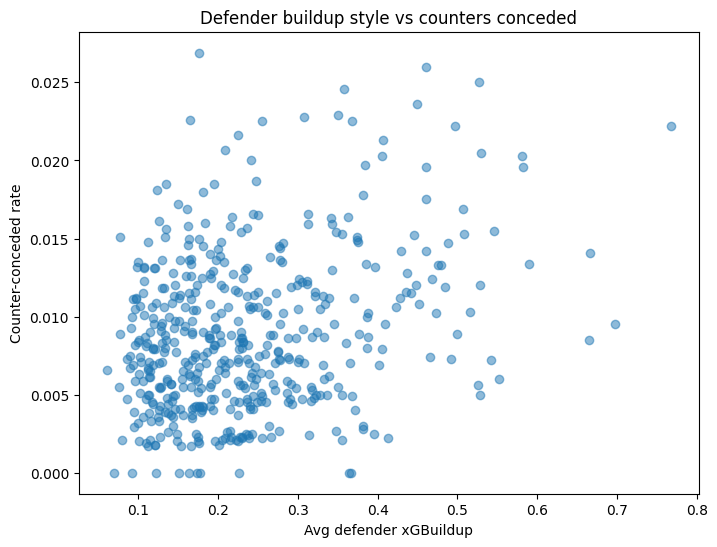

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(gk_proxy_v2['avg_xGBuildup'], gk_proxy_v2['counter_conceded_rate'], alpha=0.5)
plt.xlabel('Avg defender xGBuildup')
plt.ylabel('Counter-conceded rate')
plt.title('Defender buildup style vs counters conceded')
plt.show()

In [32]:
gk_proxy_v2['buildup_tier'] = pd.cut(
    gk_proxy_v2['avg_xGBuildup'],
    bins=[0, 0.2, 0.4, 1.0],
    labels=['low', 'mid', 'high']
)

tier_summary = gk_proxy_v2.groupby('buildup_tier').agg(
    teams=('team_name', 'count'),
    avg_counter_conceded_rate=('counter_conceded_rate', 'mean'),
    median_counter_conceded_rate=('counter_conceded_rate', 'median'),
    avg_xGBuildup=('avg_xGBuildup', 'mean')
).round(4)

print(tier_summary)

              teams  avg_counter_conceded_rate  median_counter_conceded_rate  \
buildup_tier                                                                   
low             229                     0.0079                        0.0074   
mid             209                     0.0088                        0.0080   
high             48                     0.0135                        0.0126   

              avg_xGBuildup  
buildup_tier                 
low                  0.1426  
mid                  0.2762  
high                 0.4969  


FileNotFoundError: [Errno 2] No such file or directory: '../reports/buildup_tier_scatter.png'

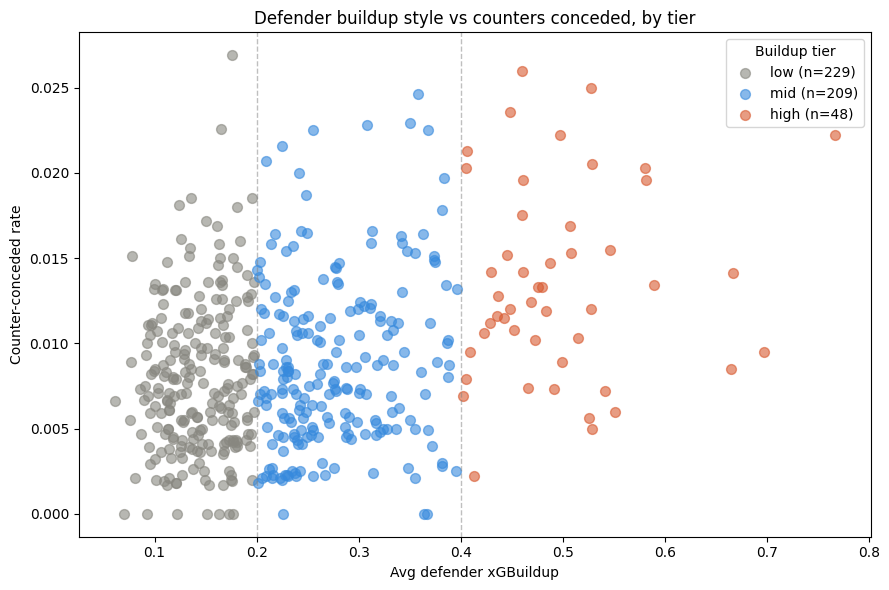

In [33]:
import matplotlib.pyplot as plt

tier_colors = {'low': '#888780', 'mid': '#378ADD', 'high': '#D85A30'}

fig, ax = plt.subplots(figsize=(9, 6))

for tier, color in tier_colors.items():
    subset = gk_proxy_v2[gk_proxy_v2['buildup_tier'] == tier]
    ax.scatter(
        subset['avg_xGBuildup'],
        subset['counter_conceded_rate'],
        alpha=0.6,
        s=50,
        color=color,
        label=f'{tier} (n={len(subset)})'
    )

# mark tier boundaries
ax.axvline(0.2, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(0.4, color='gray', linestyle='--', linewidth=1, alpha=0.5)

ax.set_xlabel('Avg defender xGBuildup')
ax.set_ylabel('Counter-conceded rate')
ax.set_title('Defender buildup style vs counters conceded, by tier')
ax.legend(title='Buildup tier')
plt.tight_layout()
plt.savefig('../reports/buildup_tier_scatter.png', dpi=150)
plt.show()


In [35]:
situation_fingerprint = shots_df.groupby('league')['situation'].value_counts(normalize=True).unstack().round(3)
print(situation_fingerprint)

situation       DirectFreekick  FromCorner  OpenPlay  Penalty  SetPiece
league                                                                 
bundesliga               0.030       0.159     0.730    0.012     0.069
la_liga                  0.036       0.155     0.731    0.014     0.064
ligue_1                  0.036       0.156     0.735    0.015     0.058
premier_league           0.032       0.166     0.731    0.011     0.061
serie_a                  0.035       0.160     0.732    0.013     0.060


In [36]:
zone_fingerprint = shots_df.groupby('league')['shot_zone'].value_counts(normalize=True).unstack().round(3)
print(zone_fingerprint)

type_fingerprint = shots_df.groupby('league')['shotType'].value_counts(normalize=True).unstack().round(3)
print(type_fingerprint)


shot_zone       edge_of_box  outside_box  six_yard_box
league                                                
bundesliga            0.367        0.023         0.610
la_liga               0.379        0.030         0.591
ligue_1               0.378        0.027         0.595
premier_league        0.377        0.016         0.606
serie_a               0.393        0.022         0.585
shotType         Head  LeftFoot  OtherBodyPart  RightFoot
league                                                   
bundesliga      0.185     0.303          0.004      0.508
la_liga         0.182     0.335          0.004      0.479
ligue_1         0.166     0.311          0.004      0.518
premier_league  0.171     0.323          0.005      0.500
serie_a         0.179     0.333          0.005      0.482


In [37]:
league_fingerprint = shots_df.groupby('league').agg(
    total_shots=('league', 'count'),
    avg_xG=('xG', 'mean'),
    conversion=('result', lambda x: (x == 'Goal').mean())
).round(3)

league_fingerprint = league_fingerprint.join(situation_fingerprint, rsuffix='_situation')
league_fingerprint = league_fingerprint.join(zone_fingerprint, rsuffix='_zone')
league_fingerprint = league_fingerprint.join(type_fingerprint, rsuffix='_type')

print(league_fingerprint.T)

league          bundesliga    la_liga    ligue_1  premier_league    serie_a
total_shots      39804.000  44850.000  42872.000       49056.000  48094.000
avg_xG               0.122      0.117      0.121           0.119      0.112
conversion           0.117      0.105      0.111           0.109      0.105
DirectFreekick       0.030      0.036      0.036           0.032      0.035
FromCorner           0.159      0.155      0.156           0.166      0.160
OpenPlay             0.730      0.731      0.735           0.731      0.732
Penalty              0.012      0.014      0.015           0.011      0.013
SetPiece             0.069      0.064      0.058           0.061      0.060
edge_of_box          0.367      0.379      0.378           0.377      0.393
outside_box          0.023      0.030      0.027           0.016      0.022
six_yard_box         0.610      0.591      0.595           0.606      0.585
Head                 0.185      0.182      0.166           0.171      0.179
LeftFoot    

In [38]:
league_fingerprint.to_csv('../data/processed/league_fingerprint.csv')
print("saved")

saved


In [39]:
def build_counter_attack_rag(league):
    league_data = league_fingerprint.loc[league]
    
    tier_data = shots_df[shots_df['league'] == league].groupby('counter_tier').agg(
        shots=('counter_tier', 'count'),
        goals=('result', lambda x: (x == 'Goal').sum()),
        avg_xG=('xG', 'mean')
    ).assign(conversion=lambda d: d['goals']/d['shots'])
    
    high_conf = tier_data.loc['high_confidence_counter']
    elevated = tier_data.loc['elevated_threat']
    regular = tier_data.loc['regular_play']
    
    league_gk = gk_proxy_v2[gk_proxy_v2['league'] == league]
    tier_means = league_gk.groupby('buildup_tier')['counter_conceded_rate'].mean()
    
    cross_data = cross_vs_open.loc[True] if 'cross_vs_open' in dir() else None
    
    block = f"""
LEAGUE: {league.replace('_', ' ').title()}
COUNTER-ATTACK PROFILE:
high_confidence_counters: {int(high_conf['shots'])} shots ({high_conf['shots']/league_data['total_shots']:.1%} of total) | avg_xG={high_conf['avg_xG']:.3f} | conversion={high_conf['conversion']:.1%}
elevated_threat: {int(elevated['shots'])} shots ({elevated['shots']/league_data['total_shots']:.1%} of total) | avg_xG={elevated['avg_xG']:.3f} | conversion={elevated['conversion']:.1%}
regular_play: avg_xG={regular['avg_xG']:.3f} | conversion={regular['conversion']:.1%}
QUALITY_MULTIPLIER: high-confidence counters convert at {high_conf['conversion']/regular['conversion']:.1f}x the rate of regular play

LEAGUE FINGERPRINT:
situation_mix: OpenPlay={league_data['OpenPlay']:.1%} | FromCorner={league_data['FromCorner']:.1%} | SetPiece={league_data['SetPiece']:.1%} | DirectFreekick={league_data['DirectFreekick']:.1%} | Penalty={league_data['Penalty']:.1%}
shot_zone_mix: six_yard_box={league_data['six_yard_box']:.1%} | edge_of_box={league_data['edge_of_box']:.1%} | outside_box={league_data['outside_box']:.1%}
shot_type_mix: RightFoot={league_data['RightFoot']:.1%} | LeftFoot={league_data['LeftFoot']:.1%} | Head={league_data['Head']:.1%}
OVERALL: avg_xG_per_shot={league_data['avg_xG']:.3f} | conversion={league_data['conversion']:.1%}

DEFENDER BUILDUP RISK:
low_buildup_tier (avg_xGBuildup~0.14): counter_conceded_rate={tier_means.get('low', 0):.3%}
mid_buildup_tier (avg_xGBuildup~0.28): counter_conceded_rate={tier_means.get('mid', 0):.3%}
high_buildup_tier (avg_xGBuildup~0.50): counter_conceded_rate={tier_means.get('high', 0):.3%}
FINDING: teams with elite possession-style defenders (xGBuildup>0.4) concede counters at roughly {tier_means.get('high',0)/tier_means.get('low',1):.1f}x the rate of low-buildup teams

INSIGHT: {league.replace('_',' ').title()} shots average {league_data['avg_xG']:.3f} xG per attempt, {'the highest' if league_data['avg_xG'] == league_fingerprint['avg_xG'].max() else 'the lowest' if league_data['avg_xG'] == league_fingerprint['avg_xG'].min() else 'mid-table'} among the top 5 leagues. Counter-attacks (high-confidence tier) convert at {high_conf['conversion']:.1%}, well above the {regular['conversion']:.1%} baseline for regular play, confirming transition moments produce disproportionately high-value chances.
"""
    return block.strip()

for league in shots_df['league'].unique():
    text = build_counter_attack_rag(league)
    with open(f'../data/rag_findings/counter_attack_{league}.txt', 'w') as f:
        f.write(text)
    print(f"saved {league}")
    print(text)
    print("\n" + "="*80 + "\n")

saved ligue_1
LEAGUE: Ligue 1
COUNTER-ATTACK PROFILE:
high_confidence_counters: 380 shots (0.9% of total) | avg_xG=0.260 | conversion=25.8%
elevated_threat: 10921 shots (25.5% of total) | avg_xG=0.190 | conversion=17.3%
regular_play: avg_xG=0.095 | conversion=8.8%
QUALITY_MULTIPLIER: high-confidence counters convert at 2.9x the rate of regular play

LEAGUE FINGERPRINT:
situation_mix: OpenPlay=73.5% | FromCorner=15.6% | SetPiece=5.8% | DirectFreekick=3.6% | Penalty=1.5%
shot_zone_mix: six_yard_box=59.5% | edge_of_box=37.8% | outside_box=2.7%
shot_type_mix: RightFoot=51.8% | LeftFoot=31.1% | Head=16.6%
OVERALL: avg_xG_per_shot=0.121 | conversion=11.1%

DEFENDER BUILDUP RISK:
low_buildup_tier (avg_xGBuildup~0.14): counter_conceded_rate=0.802%
mid_buildup_tier (avg_xGBuildup~0.28): counter_conceded_rate=0.933%
high_buildup_tier (avg_xGBuildup~0.50): counter_conceded_rate=1.210%
FINDING: teams with elite possession-style defenders (xGBuildup>0.4) concede counters at roughly 1.5x the rate of

In [42]:
import json

with open('../eval/eval_questions.json', 'r') as f:
    eval_questions = json.load(f)

print(json.dumps(eval_questions[:2], indent=2))
print(f"\nTotal so far: {len(eval_questions)}")

[
  {
    "question": "Which Premier League team has the most heists across 5 seasons?",
    "tool": "RAG",
    "answer": "Wolverhampton Wanderers \u2014 26 heists across 5 seasons"
  },
  {
    "question": "What is Liverpool's xGD defence verdict?",
    "tool": "RAG",
    "answer": "systematic_defensive_overperformer \u2014 solid 5/5 seasons"
  }
]

Total so far: 14


In [43]:
new_questions = [
    {
        "question": "Which league has the highest-converting counter-attacks?",
        "tool": "RAG",
        "answer": "Bundesliga — high-confidence counters convert at 27.4%, the highest of the top 5 leagues"
    },
    {
        "question": "How much more likely is a counter-attack shot to score compared to regular play?",
        "tool": "RAG",
        "answer": "Roughly 2.8-2.9x — high-confidence counters convert at 24-27% depending on league, vs 8-9% for regular play"
    },
    {
        "question": "Do teams with high defender xGBuildup concede more counter-attacks?",
        "tool": "RAG",
        "answer": "Yes — teams in the high buildup tier (avg xGBuildup > 0.4, elite possession sides) concede counters at roughly 1.5-1.7x the rate of low-buildup teams"
    },
    {
        "question": "Which league has the lowest average xG per shot?",
        "tool": "RAG",
        "answer": "Serie A — 0.112 avg xG per shot, the lowest among the top 5 leagues, consistent with its defensively compact reputation"
    },
    {
        "question": "How many shots did a specific team take from six-yard-box zone last season?",
        "tool": "DuckDB",
        "answer": "Query shots.csv filtered by team_name, year, shot_zone='six_yard_box' — count varies per team"
    },
    {
        "question": "Is shot quality while losing worse in added time than earlier in the match?",
        "tool": "RAG",
        "answer": "Yes — avg xG for losing teams drops steadily from 0.097 (Q1) to 0.083 (added time), while winning-by-2+ teams' avg xG rises from 0.198 to 0.211 over the same span, showing added time is the most polarized phase"
    }
]

eval_questions.extend(new_questions)

with open('../eval/eval_questions.json', 'w') as f:
    json.dump(eval_questions, f, indent=2)

print(f"Total questions now: {len(eval_questions)}")

Total questions now: 20


In [44]:
shots_df.to_csv('../data/processed/shots_enriched.csv', index=False)
print("saved shots_enriched.csv with shape:", shots_df.shape)
print(shots_df.columns.tolist())

saved shots_enriched.csv with shape: (224676, 38)
['id', 'minute', 'result', 'X', 'Y', 'xG', 'player', 'h_a', 'player_id', 'situation', 'season', 'shotType', 'match_id', 'h_team', 'a_team', 'h_goals', 'a_goals', 'date', 'player_assisted', 'lastAction', 'league', 'year', 'phase', 'goal_diff', 'game_state', 'cross_side', 'is_cross', 'shot_zone', 'prev_match_id', 'prev_h_a', 'prev_minute', 'is_rapid_transition', 'counter_score', 'is_counter', 'counter_tier', 'cross_zone', 'team_name', 'opponent_team']
